|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Understand and design CNNs<h1>|
|<h2>Lecture:</h2>|<h1><b>Find the Gaussian!<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# model summary info
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Create Gaussian blurs with different widths

In [178]:
nGauss  = 1000
imgSize = 91

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# initialize tensors containing images and labels
images = torch.zeros(nGauss,1,imgSize,imgSize)
labels = torch.zeros(nGauss,3)

for i in range(nGauss):

  # location and width parameters
  loc = np.max(x)/2 * np.random.randn(2) # center coordinate
  wid = np.random.rand()*10 + 5 # width of Gaussian

  # create the gaussian with random centers
  G  = np.exp( -( (X-loc[0])**2 + (Y-loc[1])**2) / wid )
  G  = G + 0.1 * np.random.randn(imgSize,imgSize)
  G = (G - G.min()) / (G.max() - G.min())

  # add to the tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
  labels[i,:] = torch.Tensor( [loc[0],loc[1],wid] )

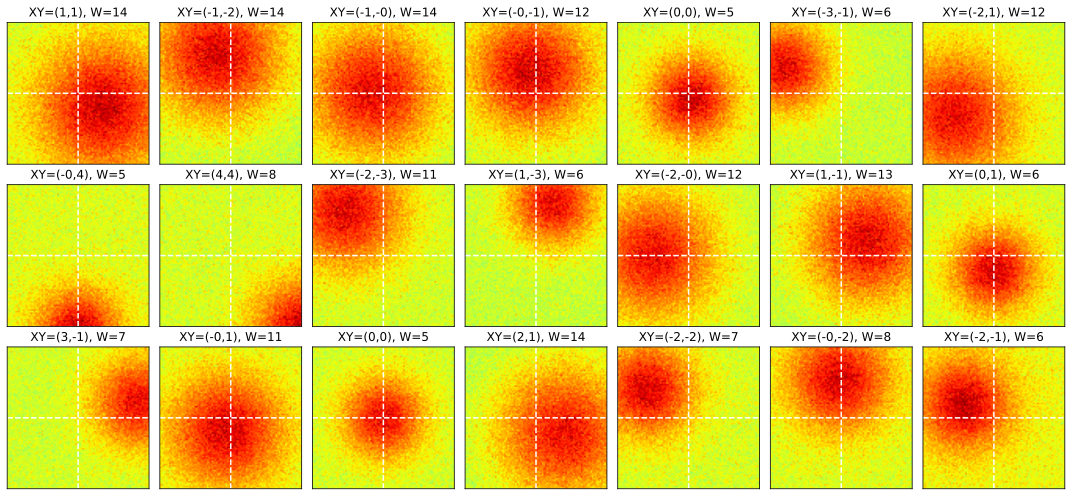

In [179]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(15,7))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(nGauss)
  G = np.squeeze( images[whichpic,:,:] )
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet',extent=[-4,4,-4,4],origin='upper')
  ax.set_title(f'XY=({labels[whichpic,0]:.0f},{labels[whichpic,1]:.0f}), W={labels[whichpic,2]:.0f}')
  ax.plot([-4,4],[0,0],'w--')
  ax.plot([0,0],[-4,4],'w--')
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

# Create train/test groups using DataLoader

In [180]:
# use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(images, labels, test_size=.1)

# convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# translate into dataloader objects
batchsize    = 16
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [181]:
# check size (should be images X channels X width X height
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )

torch.Size([900, 1, 91, 91])
torch.Size([900, 3])


# Create the DL model

In [245]:
# create a class for the model
def makeTheNet():

  class gausnet(nn.Module):
    def __init__(self):
      super().__init__()

      # all layers in one go using nn.Sequential
      self.enc = nn.Sequential(

          # conv/pool block 1
          nn.Conv2d(1,6,3,padding=1),  # output size: (91+2*1-3)/1 + 1 = 91
          nn.ReLU(),                   #
          nn.AvgPool2d(2,2),           # output size: 91/2 = 45

          # conv/pool block 2
          nn.Conv2d(6,8,3,padding=1),  # output size: (45+2*1-3)/1 + 1 = 45
          nn.ReLU(),                   #
          # nn.AvgPool2d(2,2),           # output size: 45/2 = 22
          nn.AvgPool2d(4,4),           # output size: 45/4 = 11

          # linear decision layer
          nn.Flatten(),                # vectorize conv2 block output
          # nn.Linear(22*22*4,50),       # output size: 50
          # nn.Linear(50,3),             # output size: 3
          
          nn.Linear(11*11*8,50),       # output size: 50
          nn.Linear(50,3),             # output size: 3
      )

    def forward(self,x):
      return self.enc(x)

  # create the model instance
  net = gausnet()

  # loss function
  lossfun = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [246]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet()

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print(yHat)
print(' ')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,y)
print(' ')
print('Loss:')
print(loss)

tensor([[ 0.0707, -0.0945,  0.0455],
        [ 0.0680, -0.0980,  0.0443],
        [ 0.0724, -0.0919,  0.0461],
        [ 0.0633, -0.0990,  0.0451],
        [ 0.0679, -0.0963,  0.0445],
        [ 0.0712, -0.0927,  0.0474],
        [ 0.0661, -0.0974,  0.0449],
        [ 0.0678, -0.0968,  0.0456],
        [ 0.0698, -0.0951,  0.0437],
        [ 0.0649, -0.0982,  0.0441],
        [ 0.0678, -0.1010,  0.0438],
        [ 0.0727, -0.0928,  0.0453],
        [ 0.0697, -0.0935,  0.0456],
        [ 0.0655, -0.1000,  0.0446],
        [ 0.0691, -0.0918,  0.0470],
        [ 0.0716, -0.0942,  0.0440]], grad_fn=<AddmmBackward0>)
 
torch.Size([16, 3])
 
Loss:
tensor(41.0874, grad_fn=<MseLossBackward0>)


In [247]:
# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         AvgPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 8, 45, 45]             440
              ReLU-5            [-1, 8, 45, 45]               0
         AvgPool2d-6            [-1, 8, 11, 11]               0
           Flatten-7                  [-1, 968]               0
            Linear-8                   [-1, 50]          48,450
            Linear-9                    [-1, 3]             153
Total params: 49,103
Trainable params: 49,103
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.11
Params size (MB): 0.19
Estimated Total Size (MB): 1.33
---------------------------------------------

# Create a function that trains the model

In [248]:
# a function that trains the model

def function2trainTheModel():

  # number of epochs
  numepochs = 30

  # create a new model
  net,lossfun,optimizer = makeTheNet()

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)


  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())
    # end of batch loop...

    # and get average losses across the batches
    trainLoss[epochi] = np.mean(batchLoss)

    # test accuracy
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)

    # extract the loss for this test epoch
    testLoss[epochi] = loss.item()

  # end epochs

  # function output
  return trainLoss,testLoss,net

# Run the model and show the results!

In [249]:
trainLoss,testLoss,net = function2trainTheModel()

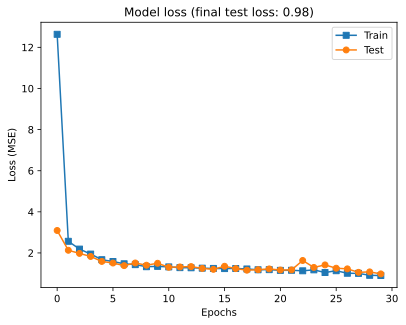

In [250]:
plt.plot(trainLoss,'s-',label='Train')
plt.plot(testLoss,'o-',label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Model loss (final test loss: %.2f)'%testLoss[-1])

plt.show()

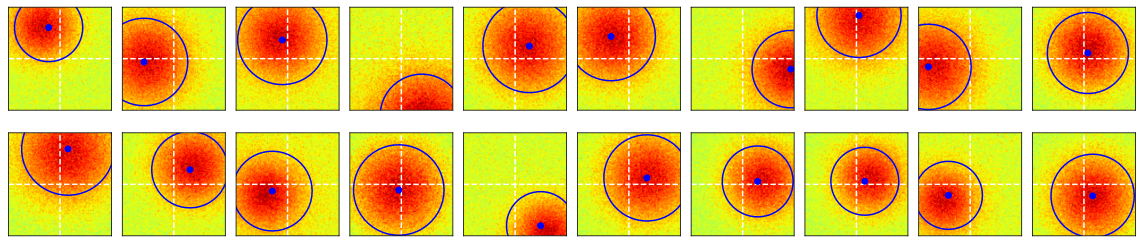

In [251]:
# visualize some images

X,Y = next(iter(test_loader)) # extract X,y from test dataloader
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(16,4))

th = np.linspace(0,2*np.pi)

for i,ax in enumerate(axs.flatten()):

  # get the Gaussian and draw it, and draw the white guide-lines
  G = torch.squeeze( X[i,0,:,:] ).detach()
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet',extent=[-4,4,-4,4],origin='lower')
  ax.plot([-4,4],[0,0],'w--')
  ax.plot([0,0],[-4,4],'w--')

  # compute the model's prediction
  cx = yHat[i][0].item() # center X
  cy = yHat[i][1].item() # center Y
  rd = yHat[i][2].item() # radius

  # and draw it
  x = cx + np.cos(th)*np.sqrt(rd)
  y = cy + np.sin(th)*np.sqrt(rd)
  ax.plot(x,y,'b')
  ax.plot(cx,cy,'bo')

  # some final plotting niceties
  ax.set_xticks([])
  ax.set_yticks([])
  ax.set_xlim([-4,4])
  ax.set_ylim([-4,4])

plt.tight_layout()
plt.show()

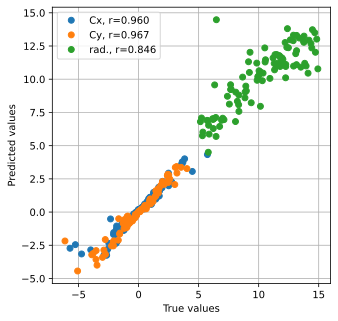

In [252]:
fig = plt.figure(figsize=(5,5))

paramNames = ['Cx','Cy','rad.']

for i in range(3):

  # extract parameters and compute correlation
  yy = Y[:,i].detach()
  yh = yHat[:,i].detach()
  cr = np.corrcoef(yy,yh)[0,1]

  # plot with label
  plt.plot(yy,yh,'o',label=f'{paramNames[i]}, r={cr:.3f}')


plt.legend()
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.grid()
plt.show()

# Additional explorations

In [ ]:
# 1) Is this model robust to noise? Explore this by increasing the amount of noise added to each stimulus. You can set
#    this up as a parametric experiment if you want, but you can also do it informally, by changing the gain factor of
#    the noise to see whether performance noticeably declines when the images get noisier. Does changing the noise affect
#    the center coordinates or the width more? And what do the results tell you about the power -- or limitations -- of
#    using CNNs for finding features in images?
# Answers: The model is in general fairly robust to noise. The noise affects the width estimation more than the center coordinates.
# It can be seen from parameter's correlation coefficients.
# The power of CNNs lies in their ability to extract spatial features even in the presence of noise, but limitations arise when noise levels become too high,
# potentially obscuring key features necessary for accurate parameter estimation.
#
# 2) You can see from the code that I didn't change the model architecture -- I literally copy/pasted it from the previous
#    Gaussian codes and only added 3 units at the end. Do you think you can develop a different architecture, possibly
#    simpler, that achieves comparable performance while reducing learning time?
# Answer: Current model has Linear-8 with around 96k parameters and final loss of around 0.93, with Cx_r = 0.959, Cy_r = 0.964 and R_r = 0.866. 
# Changing the model to:
# ----------------------------------------------------------------
#         Layer (type)               Output Shape         Param #
# ================================================================
#             Conv2d-1            [-1, 6, 91, 91]              60
#               ReLU-2            [-1, 6, 91, 91]               0
#          AvgPool2d-3            [-1, 6, 45, 45]               0
#             Conv2d-4            [-1, 8, 45, 45]             440
#               ReLU-5            [-1, 8, 45, 45]               0
#          AvgPool2d-6            [-1, 8, 11, 11]               0
#            Flatten-7                  [-1, 968]               0
#             Linear-8                   [-1, 50]          48,450
#             Linear-9                    [-1, 3]             153
# ================================================================
# Total params: 49,103
# Trainable params: 49,103
# Non-trainable params: 0
# ----------------------------------------------------------------
# Input size (MB): 0.03
# Forward/backward pass size (MB): 1.11
# Params size (MB): 0.19
# Estimated Total Size (MB): 1.33
#
#
# ... significantly reduces the number of parameters to around 49k, while achieving a final loss of around 0.98, with Cx_r = 0.96, Cy_r = 0.967 and R_r = 0.846.
#